In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [53]:
train = pd.read_csv("airbnb_train.csv")
valid = pd.read_csv("airbnb_valid.csv")
test = pd.read_csv("airbnb_test.csv")

X_train = train.drop("price", axis=1)
y_train = train["price"]

X_valid = valid.drop("price", axis=1)
y_valid = valid["price"]

cols_to_drop = ["name", "host_name", "last_review"]

Structured features: 221
Text (multi-hot) features: 527
Final X_train_v5 shape: (12223, 748)
Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 26936.3340 - root_mean_squared_error: 164.1229 - val_loss: 21851.6992 - val_root_mean_squared_error: 147.8232
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 13000.7432 - root_mean_squared_error: 114.0208 - val_loss: 7033.3560 - val_root_mean_squared_error: 83.8651
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6424.3882 - root_mean_squared_error: 80.1523 - val_loss: 6089.4058 - val_root_mean_squared_error: 78.0346
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5786.3989 - root_mean_squared_error: 76.0684 - val_loss: 5759.8521 - val_root_mean_squared_error: 75.8937
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5541.3589 - root_mean_squared_error: 74.4403 - val_loss: 5563.8955 - val_root_mean_squared_error: 74.5915
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5338.5952 - root_

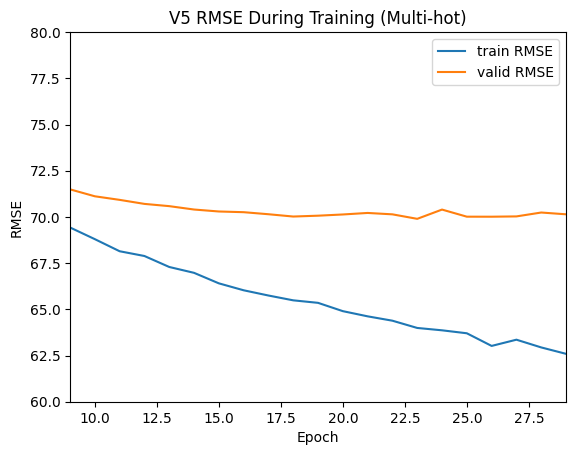

In [54]:
# Version 5: adding multi hot encoding

### Step 1: Preprocessing

# target
y_train_v5 = train["price"].values
y_valid_v5 = valid["price"].values

# V4 improvements
for df in [train, valid]:
    df["location_feature"] = df["latitude"] * df["longitude"]
    df["reviews_ratio"] = df["number_of_reviews"] / (df["availability_365"] + 1)

# structured features
drop_struct_cols = ["name", "host_name", "last_review"]

X_train_struct = X_train.drop(columns=drop_struct_cols)
X_valid_struct = X_valid.drop(columns=drop_struct_cols)

# Handle missing values
X_train_struct = X_train_struct.fillna(0)
X_valid_struct = X_valid_struct.fillna(0)

# One-hot encode categoricals in structured data
X_train_struct = pd.get_dummies(X_train_struct)
X_valid_struct = pd.get_dummies(X_valid_struct)

# Align columns so train/valid have same dummy columns
X_valid_struct = X_valid_struct.reindex(columns=X_train_struct.columns, fill_value=0)

# multi-hot text from "name"
train_text = train["name"].fillna("").astype(str)
valid_text = valid["name"].fillna("").astype(str)

# Keep vocab limited to avoid huge matrices
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    binary=True,
    min_df=10,
    max_features=2000
)

X_train_text = vectorizer.fit_transform(train_text)
X_valid_text = vectorizer.transform(valid_text)

# scale structured numeric/dummy features (helps training stability??)
scaler = StandardScaler()
X_train_struct_scaled = scaler.fit_transform(X_train_struct)
X_valid_struct_scaled = scaler.transform(X_valid_struct)

# combine structured + text
X_train_text_dense = X_train_text.toarray()
X_valid_text_dense = X_valid_text.toarray()

X_train_v5 = np.hstack([X_train_struct_scaled, X_train_text_dense])
X_valid_v5 = np.hstack([X_valid_struct_scaled, X_valid_text_dense])

print("Structured features:", X_train_struct_scaled.shape[1])
print("Text (multi-hot) features:", X_train_text_dense.shape[1])
print("Final X_train_v5 shape:", X_train_v5.shape)



### Step 2: NN Structure + Training

model_v5 = keras.Sequential([
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dense(1)  # linear output for regression
])

model_v5.compile(
    optimizer="adam",
    loss="mse",
    metrics=[keras.metrics.RootMeanSquaredError()]
)

history_v5 = model_v5.fit(
    X_train_v5,
    y_train_v5,
    epochs=30,      # from 31 onwards model starts overfitting
    batch_size=256,
    validation_data=(X_valid_v5, y_valid_v5),
    verbose=1
)



### Step 3: Visualization

# RMSE curve
plt.plot(history_v5.history["root_mean_squared_error"], label="train RMSE")
plt.plot(history_v5.history["val_root_mean_squared_error"], label="valid RMSE")
plt.xlim(9, len(history_v5.history["root_mean_squared_error"]) - 1)
plt.ylim(60, 80)
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("V5 RMSE During Training (Multi-hot)")
plt.legend()
plt.show()





In [ ]:
# Apply on test dataset

# Rpeat preprocessing steps for test

test["location_feature"] = test["latitude"] * test["longitude"]
test["reviews_ratio"] = test["number_of_reviews"] / (test["availability_365"] + 1)

test_struct = test.drop(columns=drop_struct_cols)

# Handle missing values
test_struct = test_struct.fillna(0)

# One-hot encode categoricals in structured data
test_struct = pd.get_dummies(test_struct)

# Align columns so test has same dummy columns as train/valid
test_struct = test_struct.reindex(columns=X_train_struct.columns, fill_value=0)

# multi-hot text from "name"
test_text = test["name"].fillna("").astype(str)

test_text = vectorizer.transform(test_text)

# scale structured numeric/dummy features (helps training stability??)
test_struct_scaled = scaler.transform(test_struct)

# combine structured + text
test_text_dense = test_text.toarray()

test_v5 = np.hstack([test_struct_scaled, test_text_dense])

# ======= #
# Predict #
# ======= #

test_pred = model_v5.predict(test_v5).flatten()

# Submission file
submission = pd.DataFrame({
	"index": test["index"],
	"price": test_pred
})
submission.to_csv("airbnb_submission.csv", index=False)

764/764 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [56]:
# # Version 1

# ### Step 1: Preprocessing

# cols_to_drop = ["name","host_name","last_review"]

# X_train_v1 = train.drop(["price"] + cols_to_drop, axis=1)
# y_train_v1 = train["price"]

# X_valid_v1 = valid.drop(["price"] + cols_to_drop, axis=1)
# y_valid_v1 = valid["price"]

# # One-hot encoding
# X_train_v1 = pd.get_dummies(X_train_v1)
# X_valid_v1 = pd.get_dummies(X_valid_v1)

# # Align columns
# X_valid_v1 = X_valid_v1.reindex(columns=X_train_v1.columns, fill_value=0)



# ### Step 2: NN Structure + Learning

# model_v1 = keras.Sequential([
#     layers.Dense(32, activation="relu"),
#     layers.Dense(1)
# ])

# model_v1.compile(
#     optimizer="adam",
#     loss="mse",
#     metrics=[keras.metrics.RootMeanSquaredError()]
# )

# history_v1 = model_v1.fit(
#     X_train_v1,
#     y_train_v1,
#     epochs=20,
#     batch_size=256,
#     validation_data=(X_valid_v1, y_valid_v1)
# )



# ### Step 3: Visualization

# plt.plot(history_v1.history["loss"], label="train")
# plt.plot(history_v1.history["val_loss"], label="validation")

# plt.xlabel("Epoch")
# plt.ylabel("MSE Loss")
# plt.legend()
# plt.title("Training Curve V1")
# plt.show()


In [57]:
# # Version 2

# ### Step 1: Preprocessing

# scaler = StandardScaler()

# X_train_v2 = scaler.fit_transform(X_train_v1)
# X_valid_v2 = scaler.transform(X_valid_v1)


# ### Step 2: NN Structure + Training

# model_v2 = keras.Sequential([
#     layers.Dense(64, activation="relu"),
#     layers.Dense(32, activation="relu"),
#     layers.Dense(1)
# ])

# model_v2.compile(
#     optimizer="adam",
#     loss="mse",
#     metrics=[keras.metrics.RootMeanSquaredError()]
# )

# history_v2 = model_v2.fit(
#     X_train_v2,
#     y_train_v1,
#     epochs=20,
#     batch_size=256,
#     validation_data=(X_valid_v2, y_valid_v1)
# )



# ### Step 3: Visualization

# plt.plot(history_v2.history["loss"], label="train")
# plt.plot(history_v2.history["val_loss"], label="validation")

# plt.xlabel("Epoch")
# plt.ylabel("MSE Loss")
# plt.legend()
# plt.title("Training Curve V2")
# plt.show()

In [58]:
# # Version 3

# ### Step 1: Preprocessing (same as version 2)

# X_train_v3 = X_train_v2
# X_valid_v3 = X_valid_v2

# ### Step 2: NN Structure + Training

# model_v3 = keras.Sequential([
#     layers.Dense(128, activation="relu"),
#     layers.Dropout(0.3),

#     layers.Dense(64, activation="relu"),
#     layers.Dropout(0.3),

#     layers.Dense(32, activation="relu"),
#     layers.Dense(1)
# ])

# model_v3.compile(
#     optimizer="adam",
#     loss="mse",
#     metrics=[keras.metrics.RootMeanSquaredError()]
# )

# history_v3 = model_v3.fit(
#     X_train_v3,
#     y_train_v1,
#     epochs=30,
#     batch_size=256,
#     validation_data=(X_valid_v3, y_valid_v1)
# )

# ### Step 3: Visualization

# plt.plot(history_v3.history["loss"], label="train")
# plt.plot(history_v3.history["val_loss"], label="validation")

# plt.xlabel("Epoch")
# plt.ylabel("MSE Loss")
# plt.legend()
# plt.title("Training Curve V3")
# plt.show()

In [59]:
# # Version 4

# ### Step 1: Preprocessing

# for df in [train, valid]:
#     df["location_feature"] = df["latitude"] * df["longitude"]
#     df["reviews_ratio"] = df["number_of_reviews"] / (df["availability_365"] + 1)

# X_train_v4 = train.drop(["price"] + cols_to_drop, axis=1)
# y_train_v4 = train["price"]

# X_valid_v4 = valid.drop(["price"] + cols_to_drop, axis=1)
# y_valid_v4 = valid["price"]

# X_train_v4 = pd.get_dummies(X_train_v4)
# X_valid_v4 = pd.get_dummies(X_valid_v4)

# X_valid_v4 = X_valid_v4.reindex(columns=X_train_v4.columns, fill_value=0)

# scaler = StandardScaler()

# X_train_v4 = scaler.fit_transform(X_train_v4)
# X_valid_v4 = scaler.transform(X_valid_v4)


# ### Step 2: NN Structure + Training

# model_v4 = keras.Sequential([
#     layers.Dense(128, activation="relu"),
#     layers.Dense(64, activation="relu"),
#     layers.Dense(32, activation="relu"),
#     layers.Dense(1)
# ])

# model_v4.compile(
#     optimizer="adam",
#     loss="mse",
#     metrics=[keras.metrics.RootMeanSquaredError()]
# )

# history_v4 = model_v4.fit(
#     X_train_v4,
#     y_train_v4,
#     epochs=30,
#     batch_size=256,
#     validation_data=(X_valid_v4, y_valid_v4)
# )

# ### Step 3: Visualization

# plt.plot(history_v4.history["loss"], label="train")
# plt.plot(history_v4.history["val_loss"], label="validation")

# plt.xlabel("Epoch")
# plt.ylabel("MSE Loss")
# plt.legend()
# plt.title("Training Curve V4")
# plt.show()